# 04 — Avaliação e Interpretação

Aqui a análise deixa de ser técnica e passa a ser de negócio. Os modelos treinados no notebook 03
são avaliados no **conjunto de teste**, que nenhum modelo viu durante o treino ou a validação
cruzada. Depois vêm a interpretação das variáveis e as implicações para a concessão de crédito.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

sys.path.insert(0, str(Path("..").resolve()))
from src import config
assert config.RANDOM_STATE == RANDOM_STATE

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")
config.FIGURES.mkdir(parents=True, exist_ok=True)

In [2]:
import joblib
from sklearn.dummy import DummyClassifier

from src.data import load_processed
from src.evaluation import comparison_table, recall_at_top, score
from src.models import NOMES
from src.preprocessing import split

df = load_processed(config.PROCESSED_FILE)
X_train, X_test, y_train, y_test = split(df)
# Carrega apenas o artefato gerado localmente pelo notebook 03 (joblib usa pickle).
modelos = joblib.load(config.MODELS / "modelos.joblib")
probs = {nome: m.predict_proba(X_test)[:, 1] for nome, m in modelos.items()}
print("Teste:", X_test.shape, "| maus pagadores no teste:", int(y_test.sum()))

Teste: (7292, 20) | maus pagadores no teste: 123


## 1. Métricas no conjunto de teste

In [3]:
LIMIAR = 0.5
resultados = {NOMES[n]: score(y_test, (p >= LIMIAR).astype(int), p) for n, p in probs.items()}

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
resultados["Baseline (sempre 'bom')"] = score(y_test, dummy.predict(X_test), dummy.predict_proba(X_test)[:, 1])

tabela = comparison_table(resultados, name="metricas_teste", sort_by="roc_auc")
melhor = tabela.drop("Baseline (sempre 'bom')").index[0]
melhor_chave = next(k for k, v in NOMES.items() if v == melhor)
print("Melhor modelo por ROC-AUC no teste:", melhor)
tabela

Melhor modelo por ROC-AUC no teste: XGBoost


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
modelo,,,,,,
XGBoost,0.8442,0.7250,0.0637,0.6016,0.1153,0.8164
Regressão Logística,0.7696,0.7150,0.0471,0.6585,0.0879,0.7860
Random Forest,0.8974,0.6602,0.0702,0.4146,0.1200,0.7691
Árvore de Decisão,0.7770,0.6788,0.0432,0.5772,0.0803,0.7394
Baseline (sempre 'bom'),0.9831,0.5000,0.0000,0.0000,0.0000,0.5000


**Leitura:**

- **O XGBoost confirma no teste o que a validação cruzada indicou:** tem o maior ROC-AUC
  (**0,816**, próximo do 0,831 da validação, sem sinal de overfitting) e a maior acurácia
  balanceada (0,725). No corte de 0,5, ele identifica **60,2% dos maus pagadores** (recall).
- **O baseline tem a maior acurácia de todos (98,31%) e é inútil:** não encontra nenhum mau
  pagador (recall 0). É a prova de que acurácia não serve aqui.
- **O Random Forest tem acurácia de 89,7% e o maior F1 (0,120),** mas encontra só 41,5% dos maus
  pagadores.
- **A Regressão Logística encontra mais maus pagadores (65,9%),** mas gera mais alarmes falsos.
- **A precisão é baixa para todos (4% a 7%):** de cada 100 clientes marcados como risco, só de 4 a
  7 realmente viram maus pagadores. Com uma classe de 1,69%, isso é esperado, e a seção 5 mostra
  como transformar esse resultado em ganho prático.

## 2. Justificativa das métricas

**Por que estas métricas e não a acurácia:** com 98,31% de bons pagadores, a acurácia premia quem
ignora o problema. As métricas escolhidas respondem às perguntas de negócio:

| Métrica | Pergunta que responde |
|---|---|
| **ROC-AUC** (principal) | o modelo coloca os maus pagadores acima dos bons no ranking de risco? Não depende do corte escolhido |
| **Recall** | dos maus pagadores reais, quantos o modelo encontrou? |
| **Precisão** | dos clientes marcados como risco, quantos eram mesmo maus pagadores? |
| **F1** | equilíbrio entre recall e precisão |
| **Acurácia balanceada** | acerto médio nas duas classes, sem deixar a classe maior dominar |

**Qual erro custa mais caro:**

- **Falso negativo:** aprovar um mau pagador gera perda de crédito, porque o valor emprestado pode
  não voltar.
- **Falso positivo:** recusar ou mandar para análise um bom pagador custa a margem de um cliente
  perdido ou o tempo de um analista.

Em crédito, o falso negativo costuma ser bem mais caro. Por isso **recall e ROC-AUC têm prioridade
sobre a precisão**. Mesmo assim, a precisão baixa mostra que o modelo não deve recusar pedidos
sozinho.

## 3. Matriz de confusão

Regressão Logística  VN= 5531  FP= 1638  FN= 42  VP= 81
Árvore de Decisão    VN= 5595  FP= 1574  FN= 52  VP= 71
Random Forest        VN= 6493  FP=  676  FN= 72  VP= 51
XGBoost              VN= 6082  FP= 1087  FN= 49  VP= 74


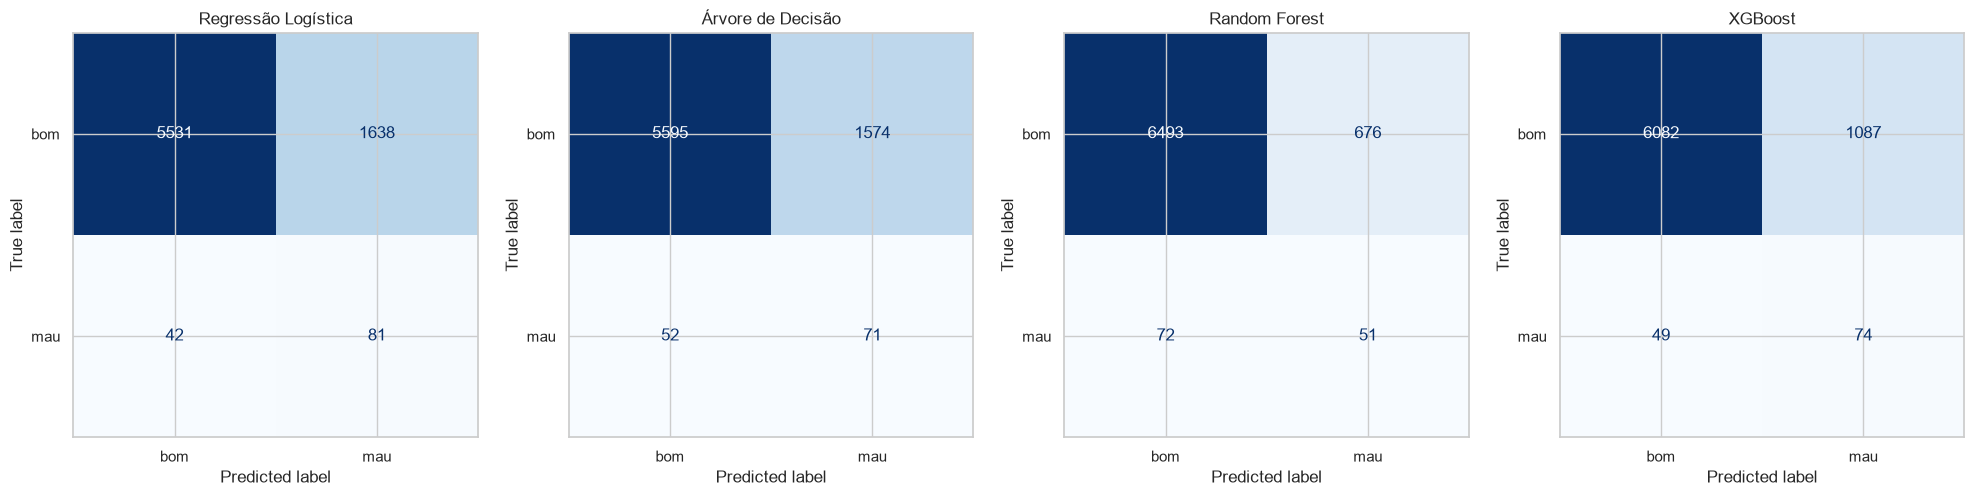

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, eixos = plt.subplots(1, 4, figsize=(20, 4.8))
for eixo, (nome, p) in zip(eixos, probs.items()):
    m = confusion_matrix(y_test, (p >= LIMIAR).astype(int))
    ConfusionMatrixDisplay(m, display_labels=["bom", "mau"]).plot(ax=eixo, cmap="Blues", colorbar=False, values_format="d")
    eixo.set_title(NOMES[nome])
    print(f"{NOMES[nome]:20s} VN={m[0,0]:5d}  FP={m[0,1]:5d}  FN={m[1,0]:3d}  VP={m[1,1]:3d}")
plt.tight_layout()
plt.savefig(config.FIGURES / "04_matrizes_confusao.png", dpi=120)
plt.show()

**Leitura (XGBoost, corte de 0,5):** dos 123 maus pagadores do teste, o modelo **identifica 74 e
deixa passar 49**. Em troca, marca como risco **1.087 bons pagadores** (15,2% dos 7.169 bons). As
alternativas mostram o trade-off:

- **Regressão Logística:** pega 81 maus pagadores, mas gera 1.638 alarmes falsos.
- **Random Forest:** gera só 676 alarmes falsos, mas deixa passar 72 dos 123 maus pagadores.

Nenhum modelo elimina os dois erros ao mesmo tempo. A escolha do corte (hoje 0,5) é uma decisão de
negócio: depende de quanto custa um calote comparado a um cliente bom perdido.

## 4. Curvas ROC e precisão × recall

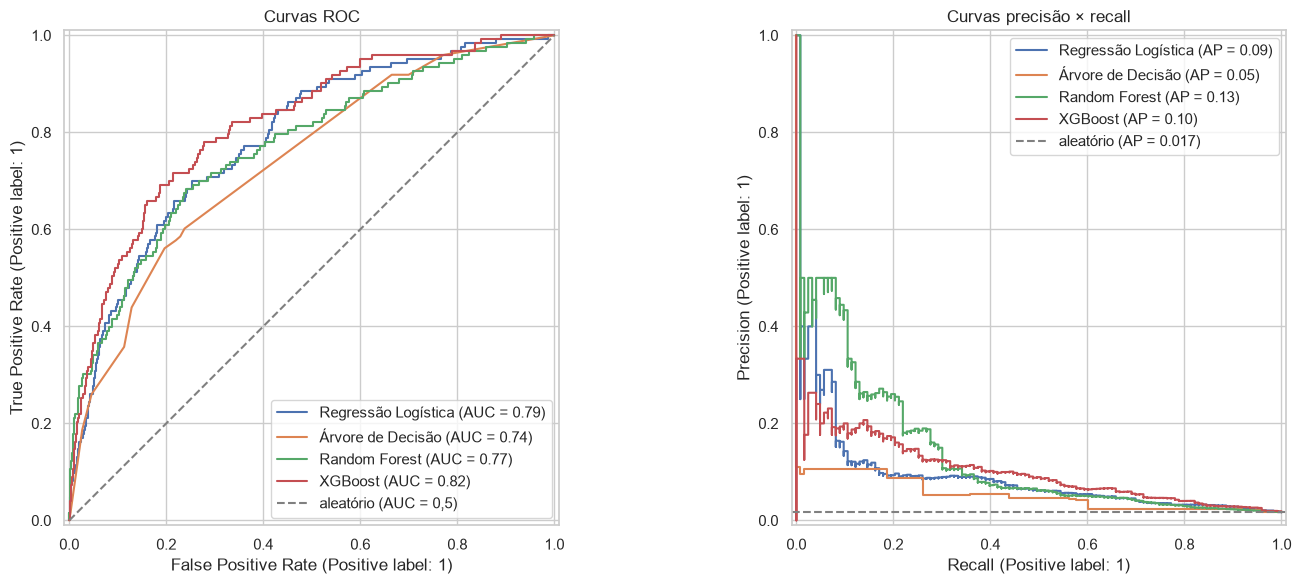

In [5]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, eixos = plt.subplots(1, 2, figsize=(15, 6))
for nome, p in probs.items():
    RocCurveDisplay.from_predictions(y_test, p, name=NOMES[nome], ax=eixos[0])
    PrecisionRecallDisplay.from_predictions(y_test, p, name=NOMES[nome], ax=eixos[1])
eixos[0].plot([0, 1], [0, 1], "--", color="gray", label="aleatório (AUC = 0,5)")
eixos[0].set_title("Curvas ROC")
eixos[0].legend(loc="lower right")
eixos[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"aleatório (AP = {y_test.mean():.3f})")
eixos[1].set_title("Curvas precisão × recall")
eixos[1].legend(loc="upper right")
plt.tight_layout()
plt.savefig(config.FIGURES / "04_curvas_roc_pr.png", dpi=120)
plt.show()

**Leitura:**

- **Curvas ROC:** a curva do XGBoost (AUC 0,82) fica acima das demais em praticamente toda a
  faixa. A exceção é o trecho inicial, com menos de cerca de 5% de alarmes falsos, onde o Random
  Forest empata com ela. A Árvore de Decisão (0,74) é claramente a mais fraca.
- **Curvas de precisão × recall:** todas ficam acima da linha do aleatório (1,7%), mas caem rápido
  quando se exige recall alto. É o retrato do desbalanceamento: encontrar quase todos os maus
  pagadores exige aceitar muitos alarmes falsos.
- **Random Forest contra XGBoost no topo do ranking:** o Random Forest tem a maior average
  precision (0,13 contra 0,10 do XGBoost), porque é mais preciso quando se olha só uma fatia muito
  pequena de clientes (recall abaixo de 0,3). A partir daí, o XGBoost mantém precisão maior.
- **Conclusão:** se a operação quisesse revisar só uma lista mínima de casos, o Random Forest seria
  uma alternativa. Para uma fila de análise de tamanho realista (seção 5), o XGBoost é superior.

## 5. Uso como ferramenta de priorização

Em vez de aprovar ou recusar pelo corte de 0,5, uma instituição pode **ordenar** os pedidos pela
probabilidade de mau pagamento e mandar para a análise manual só os mais arriscados. A tabela
mostra, para o melhor modelo, que fração dos maus pagadores reais cai dentro de cada fatia revisada.

In [6]:
fatias = [0.05, 0.10, 0.20, 0.30]
captura = pd.DataFrame({
    NOMES[n]: [recall_at_top(y_test, p, f) for f in fatias] for n, p in probs.items()
}, index=[f"top {int(f*100)}% mais arriscados" for f in fatias])
captura["Aleatório"] = fatias
captura.to_csv(config.METRICS / "captura_por_fatia.csv")
(captura * 100).round(1)

,Regressão Logística,Árvore de Decisão,Random Forest,XGBoost,Aleatório
top 5% mais arriscados,26.0000,26.0000,30.9000,33.3000,5.0000
top 10% mais arriscados,43.1000,33.3000,41.5000,50.4000,10.0000
top 20% mais arriscados,61.0000,55.3000,59.3000,69.1000,20.0000
top 30% mais arriscados,70.7000,63.4000,71.5000,78.0000,30.0000


**Leitura, e o principal resultado prático:** ordenando os pedidos pelo risco estimado pelo
XGBoost, quem revisar só os **20% mais arriscados encontra 69,1% de todos os maus pagadores**. Uma
escolha aleatória da mesma quantidade encontraria 20%. Revisando os 10% mais arriscados, já são
**50,4%**, cinco vezes mais que o acaso.

Na prática, a equipe de análise de crédito pode concentrar a análise manual em uma fração pequena
dos pedidos e ainda assim encontrar a maioria dos casos problemáticos.

## 6. E se o solicitante não tiver histórico de crédito?

As variáveis `meses_observados`, `meses_quitado` e `meses_sem_emprestimo` vêm do histórico de
crédito, que **não existe para um cliente novo**. Para medir quanto do desempenho depende delas,
treinamos o mesmo XGBoost (mesmo split, mesmos hiperparâmetros) usando **só os dados cadastrais**.

In [7]:
from src.models import get_models

colunas_historico = ["meses_observados", "meses_quitado", "meses_sem_emprestimo"]
X_train_cad = X_train.drop(columns=colunas_historico)
X_test_cad = X_test.drop(columns=colunas_historico)
so_cadastro = get_models(X_train_cad, y_train)["xgboost"].fit(X_train_cad, y_train)
p_cad = so_cadastro.predict_proba(X_test_cad)[:, 1]

cenarios = pd.DataFrame({
    "XGBoost — cadastro + histórico": score(y_test, (probs["xgboost"] >= LIMIAR).astype(int), probs["xgboost"]),
    "XGBoost — só cadastro": score(y_test, (p_cad >= LIMIAR).astype(int), p_cad),
}).T.round(4)
cenarios["captura_top_20%"] = [recall_at_top(y_test, probs["xgboost"], 0.2), recall_at_top(y_test, p_cad, 0.2)]
cenarios = cenarios.round(4)
cenarios.to_csv(config.METRICS / "cenario_so_cadastro.csv")
cenarios

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,captura_top_20%
XGBoost — cadastro + histórico,0.8442,0.7250,0.0637,0.6016,0.1153,0.8164,0.6911
XGBoost — só cadastro,0.8157,0.6466,0.0434,0.4715,0.0795,0.6579,0.4959


**Leitura, uma limitação decisiva:** sem as três variáveis de histórico, o ROC-AUC do XGBoost cai de
**0,816 para 0,658**, e a captura nos 20% mais arriscados cai de **69,1% para 49,6%**.

Os dados cadastrais sozinhos ainda carregam algum sinal (0,658 está acima do aleatório), mas **boa
parte do poder do modelo vem do histórico de relacionamento com o banco**.

Na prática:

- **Clientes que já têm histórico** (renovação, aumento de limite, cartão adicional): o modelo
  completo funciona como descrito acima.
- **Solicitantes totalmente novos:** o modelo só com o cadastro é bem mais fraco e deve ser
  complementado por fontes externas, como birôs de crédito.

## 7. Importância das variáveis

Usamos dois métodos independentes no melhor modelo:

1. **Permutation importance**: embaralha uma coluna de cada vez no teste e mede quanto o ROC-AUC
   cai, com 10 repetições por coluna.
2. **SHAP (TreeExplainer)**: calcula, para cada cliente, quanto cada variável empurrou a previsão
   para "mau" ou para "bom".

Se os dois concordam, a evidência de que o padrão é real fica mais forte.

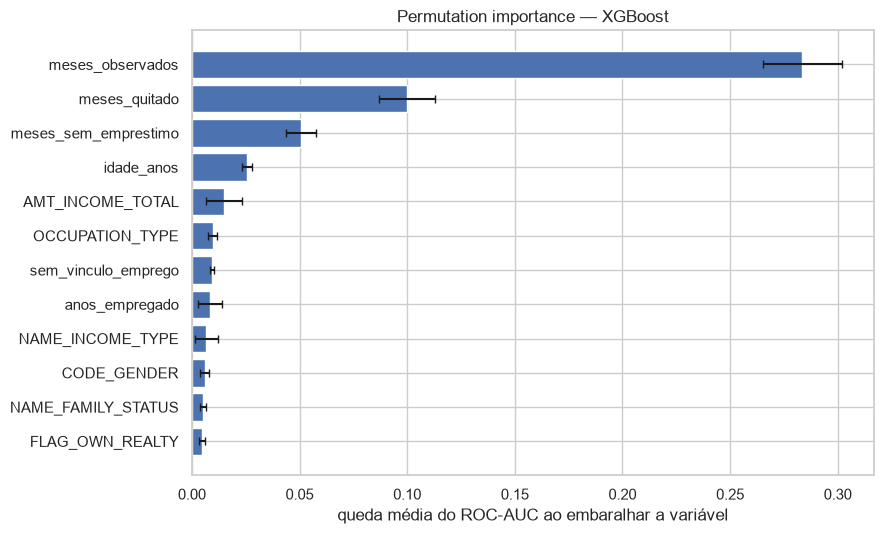

,queda_roc_auc,desvio
meses_observados,0.2836,0.0182
meses_quitado,0.0999,0.0129
meses_sem_emprestimo,0.0509,0.0069
idade_anos,0.0254,0.0023
AMT_INCOME_TOTAL,0.0150,0.0085
OCCUPATION_TYPE,0.0096,0.0020
sem_vinculo_emprego,0.0091,0.0009
anos_empregado,0.0084,0.0055
NAME_INCOME_TYPE,0.0066,0.0053
CODE_GENDER,0.0060,0.0021


In [8]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(modelos[melhor_chave], X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importancia = (pd.DataFrame({"queda_roc_auc": perm.importances_mean, "desvio": perm.importances_std},
                            index=X_test.columns)
               .sort_values("queda_roc_auc", ascending=False))
importancia.to_csv(config.METRICS / "permutation_importance.csv")

top = importancia.head(12)[::-1]
fig, eixo = plt.subplots(figsize=(9, 5.5))
eixo.barh(top.index, top["queda_roc_auc"], xerr=top["desvio"], color="C0", capsize=3)
eixo.set_xlabel("queda média do ROC-AUC ao embaralhar a variável")
eixo.set_title(f"Permutation importance — {melhor}")
plt.tight_layout()
plt.savefig(config.FIGURES / "04_permutation_importance.png", dpi=120)
plt.show()
importancia.head(12)

C:\Users\sogys\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


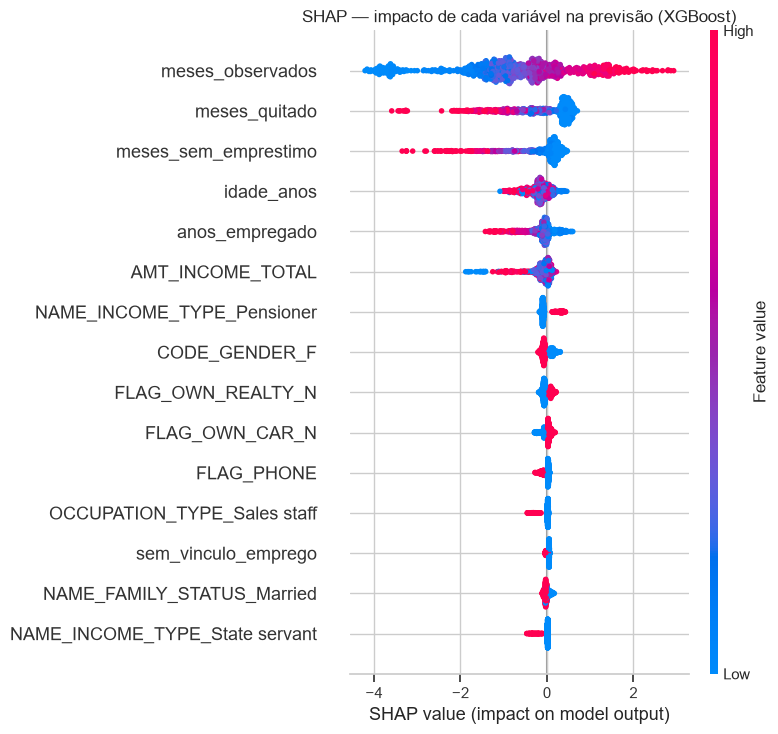

meses_observados                 1.2247
meses_quitado                    0.5929
meses_sem_emprestimo             0.3676
idade_anos                       0.2241
anos_empregado                   0.2172
AMT_INCOME_TOTAL                 0.1606
NAME_INCOME_TYPE_Pensioner       0.1293
CODE_GENDER_F                    0.0944
FLAG_OWN_REALTY_N                0.0779
FLAG_OWN_CAR_N                   0.0676
FLAG_PHONE                       0.0574
OCCUPATION_TYPE_Sales staff      0.0485
sem_vinculo_emprego              0.0448
NAME_FAMILY_STATUS_Married       0.0393
NAME_INCOME_TYPE_State servant   0.0344
dtype: float32

In [9]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
import shap

pre = modelos[melhor_chave].named_steps["pre"]
clf = modelos[melhor_chave].named_steps["clf"]
amostra = X_test.sample(1000, random_state=RANDOM_STATE)
X_amostra = pre.transform(amostra)
X_amostra = X_amostra.toarray() if hasattr(X_amostra, "toarray") else X_amostra
nomes = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]

valores_shap = shap.TreeExplainer(clf).shap_values(X_amostra)

shap.summary_plot(valores_shap, X_amostra, feature_names=nomes, max_display=15, show=False)
plt.title(f"SHAP — impacto de cada variável na previsão ({melhor})")
plt.tight_layout()
plt.savefig(config.FIGURES / "04_shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

shap_global = pd.Series(np.abs(valores_shap).mean(axis=0), index=nomes).sort_values(ascending=False)
shap_global.head(15).rename("media_abs_shap").to_csv(config.METRICS / "shap_importancia.csv")
shap_global.head(15)

**Leitura:** os dois métodos **concordam** nas três variáveis mais importantes, e todas vêm do
histórico de crédito.

1. **`meses_observados`**, disparado a mais importante (embaralhá-la derruba o ROC-AUC em 0,28).
   Pelo SHAP, **mais meses de histórico aumentam o risco previsto**. Isso reflete **tempo de
   exposição**: quem é observado por 60 meses teve 60 chances de registrar um atraso, e quem é
   observado por 3 teve só 3. Não é vazamento (não usa informação do futuro), mas significa que
   parte do que o modelo aprende é "cliente antigo", não só "cliente arriscado".
2. **`meses_quitado`** (queda de 0,10): **mais meses quitando o saldo reduzem o risco**. É um sinal
   de comportamento, faz sentido no domínio.
3. **`meses_sem_emprestimo`** (queda de 0,05): **mais meses sem crédito em uso também reduzem o
   risco**, porque indicam uso moderado do crédito.

**Entre as variáveis cadastrais:**

- **Idade e tempo de emprego:** clientes mais velhos e com mais tempo de emprego tendem a ter
  risco menor.
- **Renda:** tem efeito menor e não linear.
- **Aposentados** (`NAME_INCOME_TYPE_Pensioner`) aparecem com risco um pouco maior, o que é
  coerente com a taxa de 2,11% vista na EDA.

**Alerta de equidade:** `CODE_GENDER` tem peso mensurável no modelo (as mulheres aparecem com risco
menor). Usar gênero em decisões de crédito levanta questões legais e éticas. Antes de qualquer uso
real, é necessária uma auditoria de equidade (métricas de erro separadas por gênero) e a avaliação
de remover a variável.

## 8. Implicações práticas

1. **Usar o modelo para priorizar a análise, não para decidir sozinho.** Ordenar os pedidos pelo
   risco e revisar os 20% mais arriscados encontra cerca de 7 em cada 10 maus pagadores. A equipe
   de análise concentra esforço onde há mais risco, e os demais pedidos seguem o fluxo normal.
2. **Não automatizar a recusa.** Com precisão de cerca de 6%, recusar automaticamente todo cliente
   marcado como risco significaria negar crédito a cerca de 15 bons pagadores para cada mau pagador
   evitado. O custo comercial e reputacional seria alto.
3. **O histórico de relacionamento é o ativo mais valioso.** O modelo é bem mais forte para quem
   já é cliente (ROC-AUC 0,816) do que para quem chega sem histórico (0,658). Para clientes novos,
   combinar o modelo com birôs de crédito externos.
4. **O corte de decisão é uma escolha de negócio.** O corte de 0,5 usado aqui é didático. Com os
   custos reais de um calote e de um cliente perdido, dá para escolher o corte que minimiza o
   prejuízo total.
5. **Revisar o uso de gênero antes de produção.** A variável influencia a previsão e precisa de
   auditoria de equidade e validação jurídica.

## 9. Limitações

- **Alvo construído, não observado:** "mau pagador" foi definido como atraso de 60 dias ou mais em
  qualquer mês do histórico. Um corte de 30 dias, ou uma janela de tempo fixa, mudaria o problema.
  Com mais tempo, valeria testar alternativas e comparar a estabilidade do modelo.
- **Janela temporal:** as features de histórico e o alvo vêm do mesmo período observado. Em
  produção, o correto seria calcular as features com os meses *anteriores* a uma data de corte e
  medir o alvo nos meses *seguintes*. A base não tem datas absolutas, o que dificulta essa
  separação.
- **Tempo de exposição:** a variável mais importante mede em parte há quanto tempo o cliente é
  observado. Normalizar o alvo pelo tempo de observação (por exemplo, exigir um mínimo de meses de
  histórico) é um próximo passo natural.
- **Precisão baixa:** 6% no corte padrão. Seria possível ajustar hiperparâmetros (busca em grade
  com validação cruzada) e calibrar as probabilidades para melhorar o uso do score.
- **Equidade:** a análise por gênero e por outras variáveis sensíveis não foi feita e é
  pré-requisito para qualquer uso real.
- **Dados:** a base não traz valores de crédito, limites nem custos. Sem eles, não dá para traduzir
  os acertos e erros do modelo em valores financeiros.